In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd
import datetime

In [3]:
try:
    ee.Initialize()
except:
    # need to authenticate with your credential at the first time
    ee.Authenticate()
    ee.Initialize()

In [4]:
def maskS2clouds(image):
    qa = image.select('QA60')
    neighbor_size = 30         # 30 pixels or 300 meters
    quality_threshold = 0.05   # above 5% of cloud or shadow would be masked
    
    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    
    # Both flags should be set to zero, indicating clear conditions.Both flags should be set to zero, indicating clear conditions.
    mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
      .And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    
    """
    *  Account for shadow effect and use neighborhood average
    """
    # calculate the neighborhood average (NA) fraction of cloud (SCL 8-10)
    cldPrbNA = image.select('SCL').gte(8).And(image.select('SCL').lte(10)) \
        .reduceNeighborhood(**{
            'reducer': ee.Reducer.mean(),
            'kernel': ee.Kernel.circle(neighbor_size)
        }).rename('cldPrbNA')
    
    # calculate the neighborhood average (NA) fraction of shadow (SCL 3)
    cldShadowNA = image.select('SCL').eq(3) \
        .reduceNeighborhood(**{
            'reducer': ee.Reducer.mean(),
            'kernel': ee.Kernel.circle(neighbor_size)
        }).rename('cldShadowNA')
    
    # the NA fraction of clouds and shadow
    cldTotalNA = cldPrbNA.add(cldShadowNA)
    
    # Update the mask, cldTotalNA should be lower than quality_threshold defined above
    mask = mask.And(cldTotalNA.lt(quality_threshold))
    return image.updateMask(mask).divide(10_000) \
        .addBands(cldPrbNA).addBands(cldShadowNA) \
        .copyProperties(image, ['system:time_start'])

In [5]:
def addVegetationIndices(image):
    image = image.clip(MtPleasant)
    
    NIRv = image.expression(
        '((NIR - RED) / (NIR + RED)) * NIR',
        { 
          'NIR': image.select('B8'),
          'RED': image.select('B4')
        }).rename('NIRv')
    
    EVI = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED + 7.5 * BLUE + 1))',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')
    
    # Return the masked image with NIRv and EVI bands.
    return image.addBands(NIRv).addBands(EVI)

In [6]:
# Define study region
MtPleasant = ee.Geometry.Polygon(
    [-76.39092979365925, 42.47111031803205,
     -76.39092979365925, 42.46458902246419,
     -76.37702522212605, 42.46458902246419,
     -76.37702522212605, 42.47111031803205], None, False)

# Setup Sentinel-2 image collection over study region with low(ish) cloud cover
site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(MtPleasant) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).map(addVegetationIndices)

In [7]:
Map = geemap.Map()
rgbVis = {
  'bands': ['B4', 'B3', 'B2'],
  'min': 0,
  'max': 0.2,
}
Map.addLayer(site_images.mosaic(), rgbVis, 'Sentinel-2 Image')
Map.centerObject(MtPleasant)
display(Map)

Map(center=[20, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=(Togg…

In [8]:
# Paramters for analysis
coords = [-76.3892, 42.4693]
poi = ee.Geometry.Point(coords)
band = 'EVI'

# Reduces region of image using median, then returns a feature with the index and median value
def extract_data(image):
        stats = image.reduceRegion(
            reducer = ee.Reducer.median(),
            geometry = poi,
            scale = 10,
            #bestEffort = True,
            crs = 'EPSG:4326'
        )
        properties = {
            'system_index': image.get('system:index'),
            band: stats.get(band)
        }
        return ee.Feature(None, properties)
    
data = ee.FeatureCollection(site_images.map(extract_data))
df = geemap.ee_to_pandas(data, ['system_index', band]).dropna()

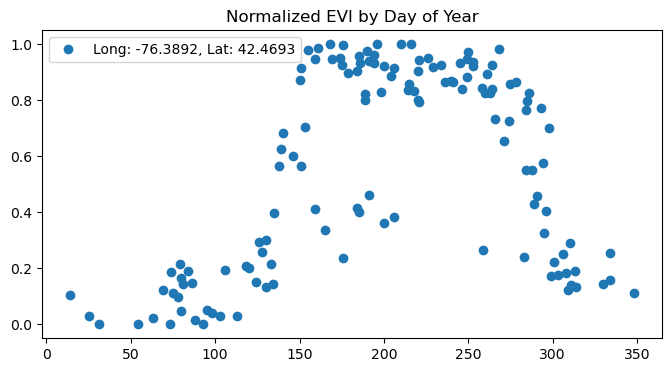

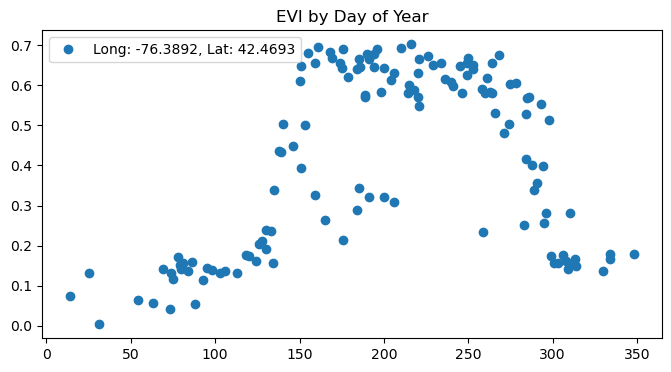

In [9]:
# Plot EVI of poi by day of year

def convert_index_to_date(index):
    return datetime.date(year = int(index[0:4]),
                         month = int(index[4:6]),
                         day = int(index[6:8]))
                


df['Date'] = df['system_index'].map(convert_index_to_date)
df['Year'] = df['Date'].map(lambda x: x.year)
df['doy'] = df['Date'].map(lambda x: x.timetuple().tm_yday)

df['EVI_nrml'] = df.groupby(['Year']).transform(lambda x: (x - x.min())/(x.max() - x.min()))['EVI']


plt.figure(figsize = (8, 4))
plt.plot(df['doy'], df['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('Normalized EVI by Day of Year')
plt.show()

plt.figure(figsize = (8, 4))
plt.plot(df['doy'], df['EVI'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('EVI by Day of Year')
plt.show()

## Remove outliers test

In [10]:
def remove_outliers(df, column):
    safe_df = df.copy()
    
    mean = safe_df[column].mean()
    std = safe_df[column].std()
    safe_df[f'{column}_z_score'] = (safe_df[column] - mean)/std
    
    mask = (safe_df[f'{column}_z_score'] <= 1) & (safe_df[f'{column}_z_score'] >= -1)
    return safe_df[mask]

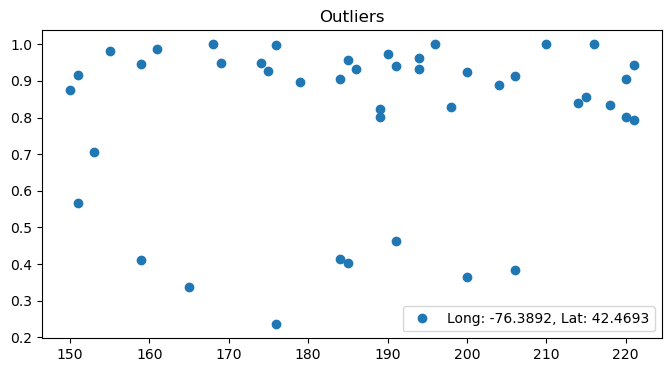

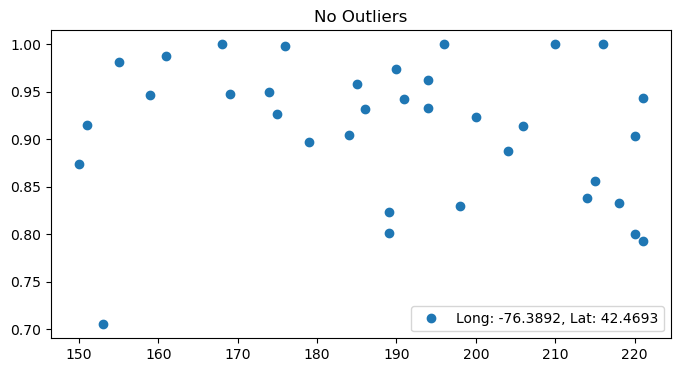

In [11]:
mask = (df['doy'] >= 150) & (df['doy'] <= 225)
new_df = remove_outliers(df[mask], 'EVI_nrml')

plt.figure(figsize = (8, 4))
plt.plot((df[mask])['doy'], (df[mask])['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('Outliers')
plt.show()

plt.figure(figsize = (8, 4))
plt.plot(new_df['doy'], new_df['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('No Outliers')
plt.show()

In [12]:
def window_remove_outliers(df, column, window_column, window_size):
    n = (df[window_column].max() - df[window_column].min()) // window_size
    clean_df = pd.DataFrame()
    
    for i in range(n):
        win_start = i*window_size + df[window_column].min()
        if i == n - 1:
            win_end = df[window_column].max() + 1
        else:
            win_end = (i+1)*window_size + df[window_column].min()
        
        mask = (df[window_column] >= win_start) & (df[window_column] < win_end)
        clean_df = clean_df.append(remove_outliers(df[mask], column))
    
    return clean_df

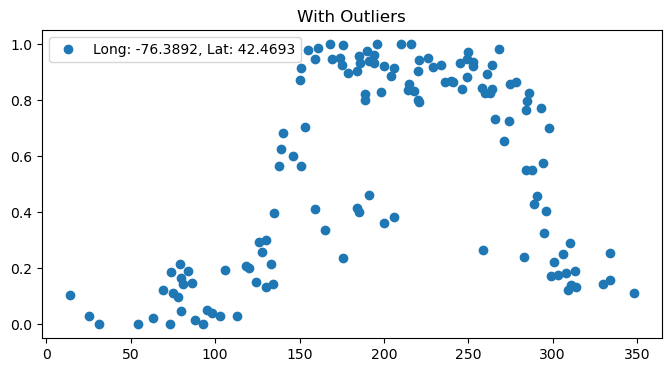

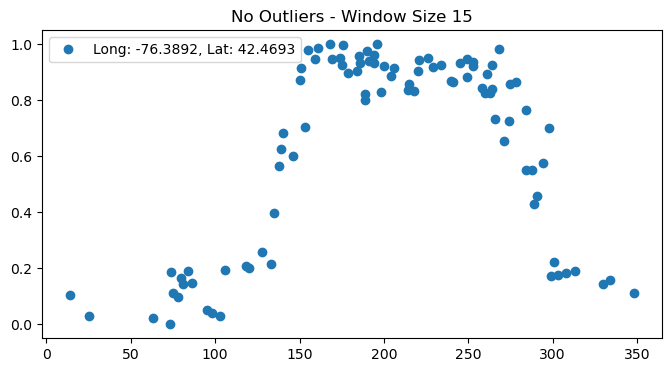

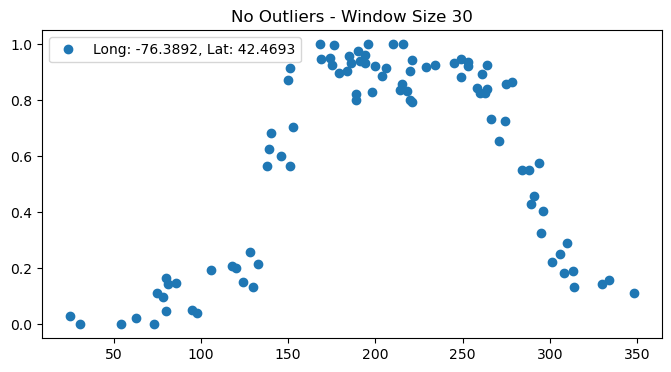

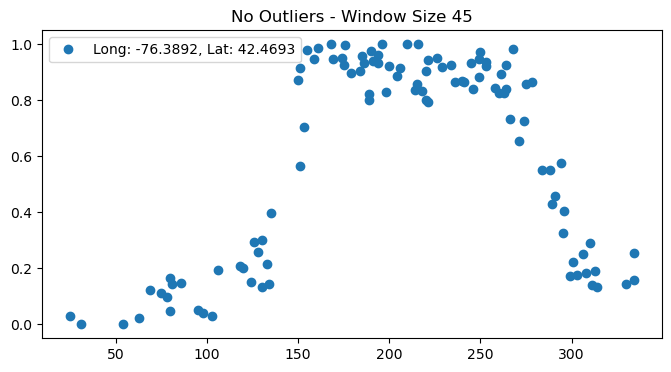

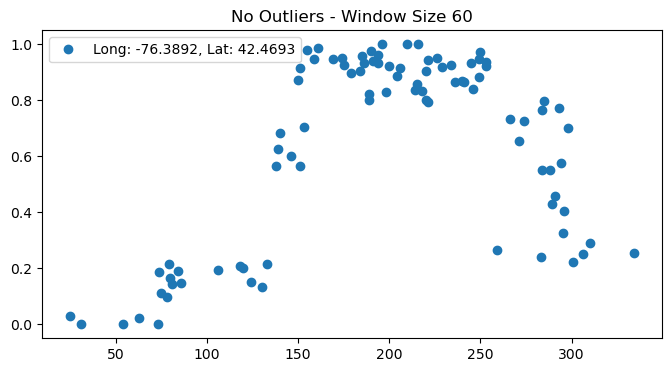

In [13]:
clean_df_15 = window_remove_outliers(df, 'EVI_nrml', 'doy', 15)
clean_df_30 = window_remove_outliers(df, 'EVI_nrml', 'doy', 30)
clean_df_45 = window_remove_outliers(df, 'EVI_nrml', 'doy', 45)
clean_df_60 = window_remove_outliers(df, 'EVI_nrml', 'doy', 60)

plt.figure(figsize = (8, 4))
plt.plot(df['doy'], df['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('With Outliers')
plt.show()

plt.figure(figsize = (8, 4))
plt.plot(clean_df_15['doy'], clean_df_15['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('No Outliers - Window Size 15')
plt.show()

plt.figure(figsize = (8, 4))
plt.plot(clean_df_30['doy'], clean_df_30['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('No Outliers - Window Size 30')
plt.show()

plt.figure(figsize = (8, 4))
plt.plot(clean_df_45['doy'], clean_df_45['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('No Outliers - Window Size 45')
plt.show()

plt.figure(figsize = (8, 4))
plt.plot(clean_df_60['doy'], clean_df_60['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.legend()
plt.title('No Outliers - Window Size 60')
plt.show()

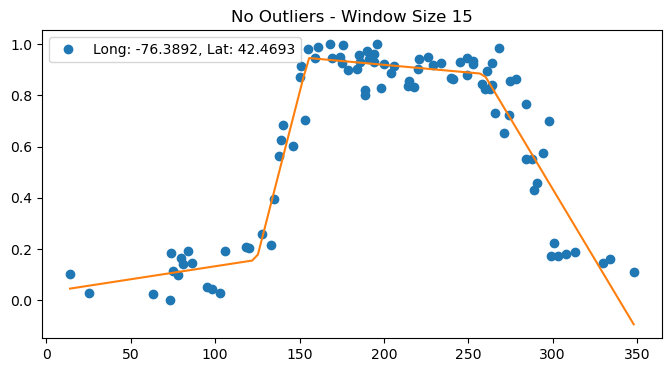

In [14]:
import pwlf
import numpy as np

model = pwlf.PiecewiseLinFit(clean_df_15['doy'], clean_df_15['EVI_nrml'])
model.fit(4)

X_grid = np.linspace(clean_df_15['doy'].min(), clean_df_15['doy'].max(), 100)
y_pred = model.predict(X_grid)

plt.figure(figsize = (8, 4))
plt.plot(clean_df_15['doy'], clean_df_15['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.plot(X_grid, y_pred)
plt.legend()
plt.title('No Outliers - Window Size 15')
plt.show()

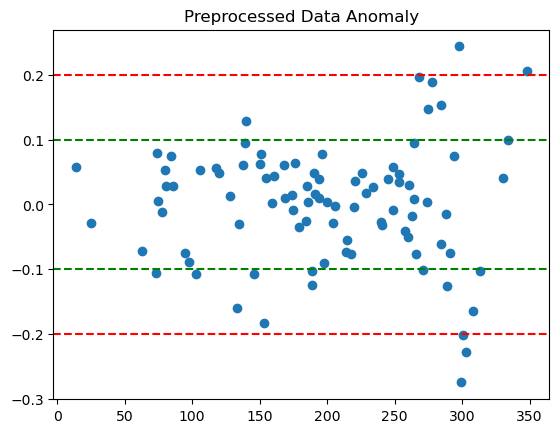

In [15]:
clean_df_15['anomaly'] = clean_df_15['EVI_nrml'] - model.predict(clean_df_15['doy'])

plt.plot(clean_df_15['doy'], clean_df_15['anomaly'], 'o')
plt.title('Preprocessed Data Anomaly')
plt.axhline(0.2, linestyle = 'dashed', color = 'red')
plt.axhline(-0.2, linestyle = 'dashed', color = 'red')
plt.axhline(0.1, linestyle = 'dashed', color = 'green')
plt.axhline(-0.1, linestyle = 'dashed', color = 'green')
plt.show()

In [16]:
copy_df = clean_df_15.copy()
copy_df['doy'] += 365

In [17]:
clean_df_15 = clean_df_15.append(copy_df)

## Testing different fitting functions

### fit

#### Speed Test

31.8 s ± 3.81 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


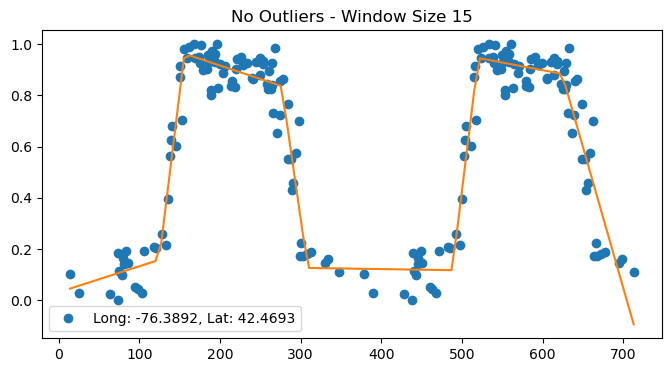

In [18]:
model = pwlf.PiecewiseLinFit(clean_df_15['doy'], clean_df_15['EVI_nrml'])
%timeit model.fit(8)

X_grid = np.linspace(clean_df_15['doy'].min(), clean_df_15['doy'].max(), 100)
y_pred = model.predict(X_grid)

plt.figure(figsize = (8, 4))
plt.plot(clean_df_15['doy'], clean_df_15['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.plot(X_grid, y_pred)
plt.legend()
plt.title('No Outliers - Window Size 15')
plt.savefig('../data/seasonaltrend.png')


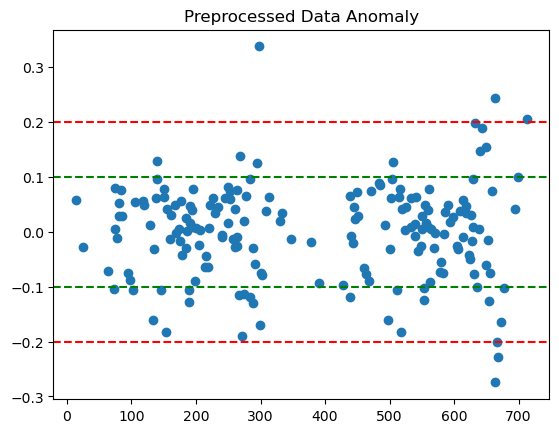

In [19]:
clean_df_15['anomaly'] = clean_df_15['EVI_nrml'] - model.predict(clean_df_15['doy'])

plt.plot(clean_df_15['doy'], clean_df_15['anomaly'], 'o')
6
plt.title('Preprocessed Data Anomaly')
plt.axhline(0.2, linestyle = 'dashed', color = 'red')
plt.axhline(-0.2, linestyle = 'dashed', color = 'red')
plt.axhline(0.1, linestyle = 'dashed', color = 'green')
plt.axhline(-0.1, linestyle = 'dashed', color = 'green')
plt.savefig('../data/anomaly.png')

#### Consistency Test

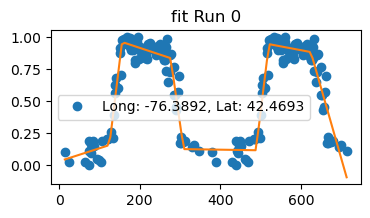

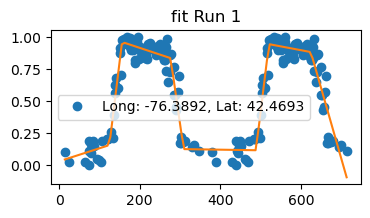

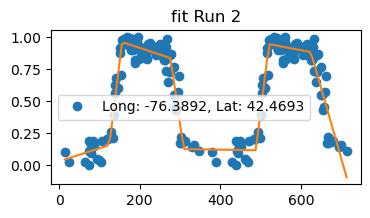

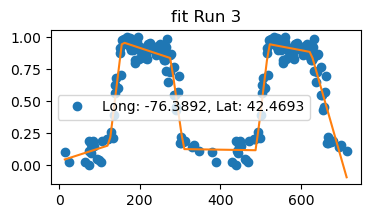

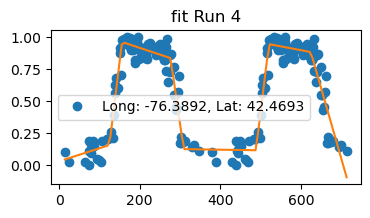

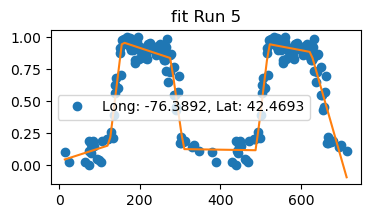

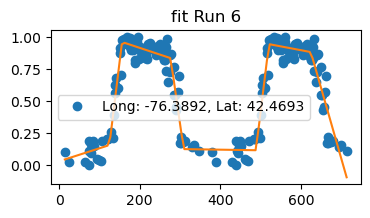

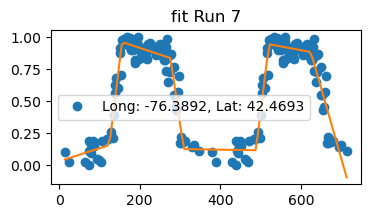

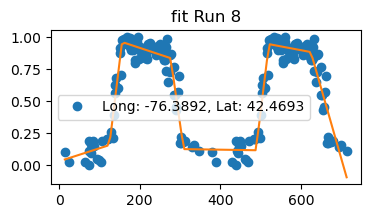

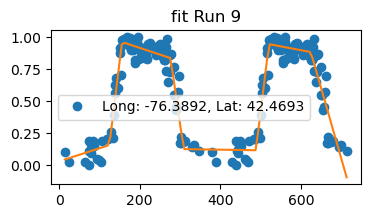

In [20]:
for i in range(10):
    model = pwlf.PiecewiseLinFit(clean_df_15['doy'], clean_df_15['EVI_nrml'])
    model.fit(8)

    X_grid = np.linspace(clean_df_15['doy'].min(), clean_df_15['doy'].max(), 100)
    y_pred = model.predict(X_grid)

    plt.figure(figsize = (4, 2))
    plt.plot(clean_df_15['doy'], clean_df_15['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
    plt.plot(X_grid, y_pred)
    plt.legend()
    plt.title(f'fit Run {i}')
    plt.show()

### fitfast

#### Speed Test

The slowest run took 4.24 times longer than the fastest. This could mean that an intermediate result is being cached.
218 ms ± 152 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


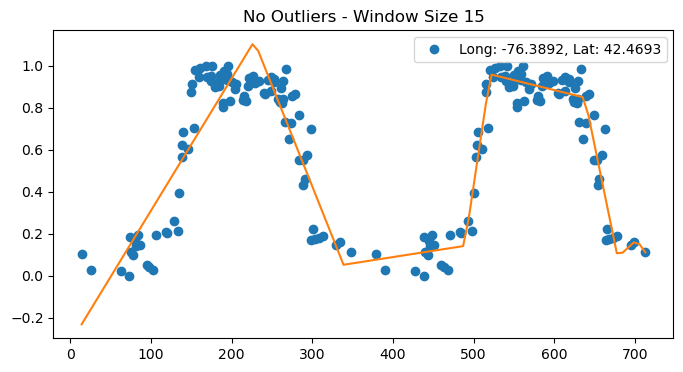

In [21]:
model = pwlf.PiecewiseLinFit(clean_df_15['doy'], clean_df_15['EVI_nrml'])
%timeit model.fitfast(8)

X_grid = np.linspace(clean_df_15['doy'].min(), clean_df_15['doy'].max(), 100)
y_pred = model.predict(X_grid)

plt.figure(figsize = (8, 4))
plt.plot(clean_df_15['doy'], clean_df_15['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.plot(X_grid, y_pred)
plt.legend()
plt.title('No Outliers - Window Size 15')
plt.show()

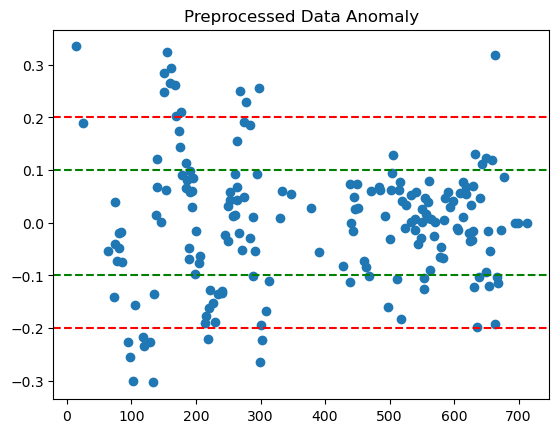

In [22]:
clean_df_15['anomaly'] = clean_df_15['EVI_nrml'] - model.predict(clean_df_15['doy'])

plt.plot(clean_df_15['doy'], clean_df_15['anomaly'], 'o')
6
plt.title('Preprocessed Data Anomaly')
plt.axhline(0.2, linestyle = 'dashed', color = 'red')
plt.axhline(-0.2, linestyle = 'dashed', color = 'red')
plt.axhline(0.1, linestyle = 'dashed', color = 'green')
plt.axhline(-0.1, linestyle = 'dashed', color = 'green')
plt.show()

#### Consistency Test

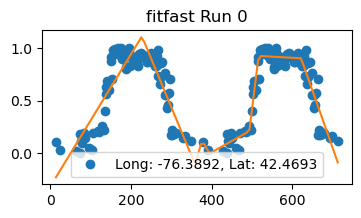

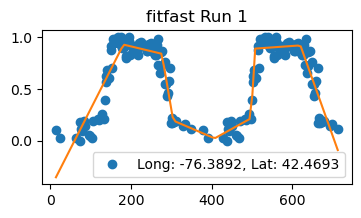

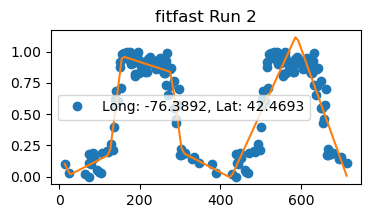

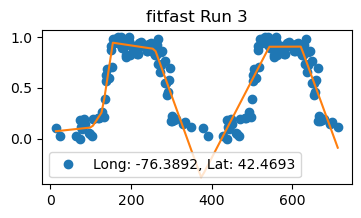

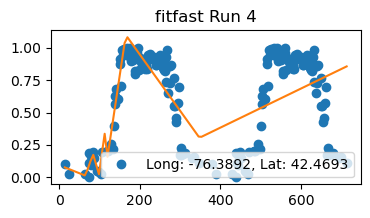

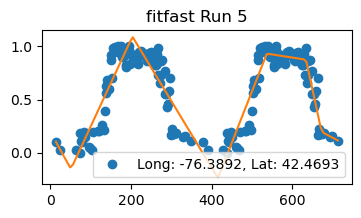

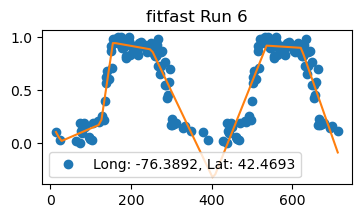

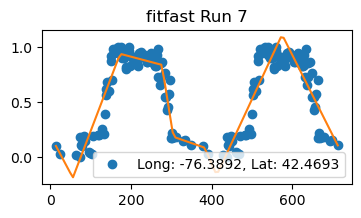

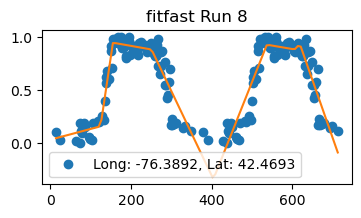

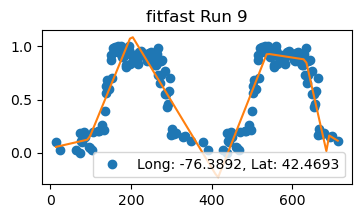

In [23]:
for i in range(10):
    model = pwlf.PiecewiseLinFit(clean_df_15['doy'], clean_df_15['EVI_nrml'])
    model.fitfast(8)

    X_grid = np.linspace(clean_df_15['doy'].min(), clean_df_15['doy'].max(), 100)
    y_pred = model.predict(X_grid)

    plt.figure(figsize = (4, 2))
    plt.plot(clean_df_15['doy'], clean_df_15['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
    plt.plot(X_grid, y_pred)
    plt.legend()
    plt.title(f'fitfast Run {i}')
    plt.show()

### fit_guess

#### Speed Test

30 ms ± 1.61 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


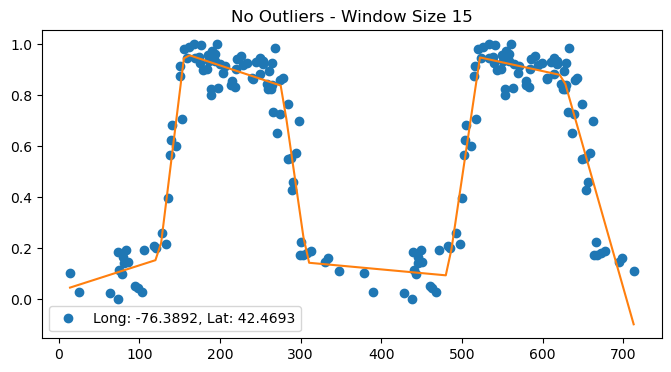

In [24]:
model = pwlf.PiecewiseLinFit(clean_df_15['doy'], clean_df_15['EVI_nrml'])
%timeit model.fit_guess([120, 150, 275, 310, 490, 540, 650])

X_grid = np.linspace(clean_df_15['doy'].min(), clean_df_15['doy'].max(), 100)
y_pred = model.predict(X_grid)

plt.figure(figsize = (8, 4))
plt.plot(clean_df_15['doy'], clean_df_15['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.plot(X_grid, y_pred)
plt.legend()
plt.title('No Outliers - Window Size 15')
plt.show()

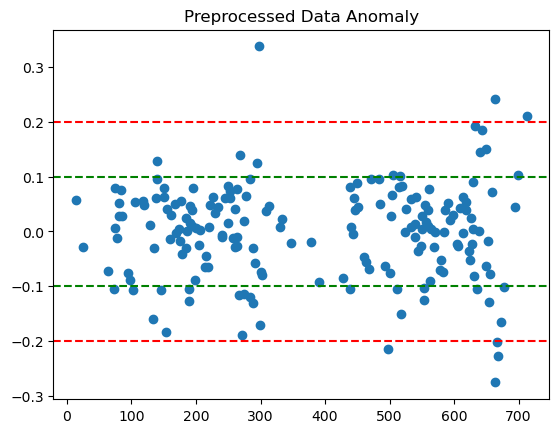

In [25]:
clean_df_15['anomaly'] = clean_df_15['EVI_nrml'] - model.predict(clean_df_15['doy'])

plt.plot(clean_df_15['doy'], clean_df_15['anomaly'], 'o')
6
plt.title('Preprocessed Data Anomaly')
plt.axhline(0.2, linestyle = 'dashed', color = 'red')
plt.axhline(-0.2, linestyle = 'dashed', color = 'red')
plt.axhline(0.1, linestyle = 'dashed', color = 'green')
plt.axhline(-0.1, linestyle = 'dashed', color = 'green')
plt.show()

#### Consistency Test

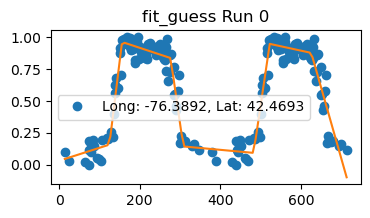

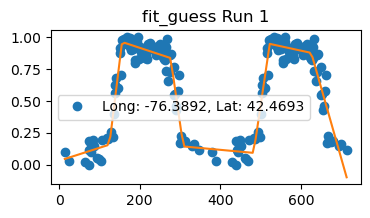

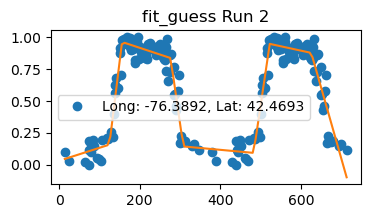

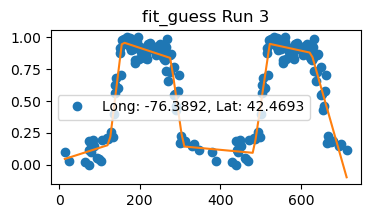

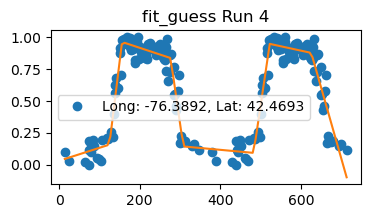

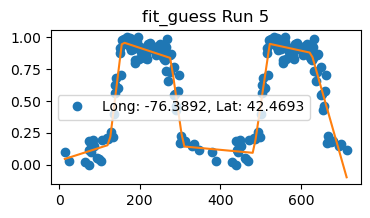

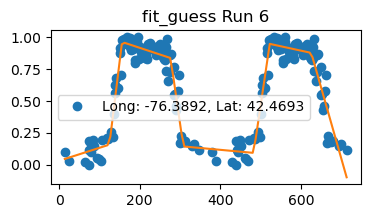

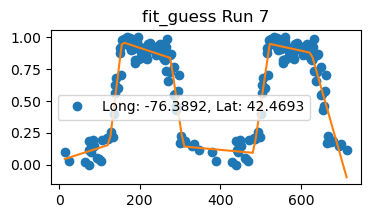

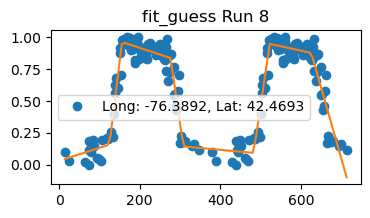

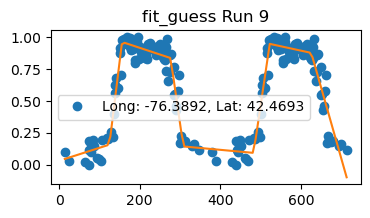

In [26]:
for i in range(10):
    model = pwlf.PiecewiseLinFit(clean_df_15['doy'], clean_df_15['EVI_nrml'])
    model.fit_guess([120, 150, 275, 310, 490, 540, 650])

    X_grid = np.linspace(clean_df_15['doy'].min(), clean_df_15['doy'].max(), 100)
    y_pred = model.predict(X_grid)

    plt.figure(figsize = (4, 2))
    plt.plot(clean_df_15['doy'], clean_df_15['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
    plt.plot(X_grid, y_pred)
    plt.legend()
    plt.title(f'fit_guess Run {i}')
    plt.show()

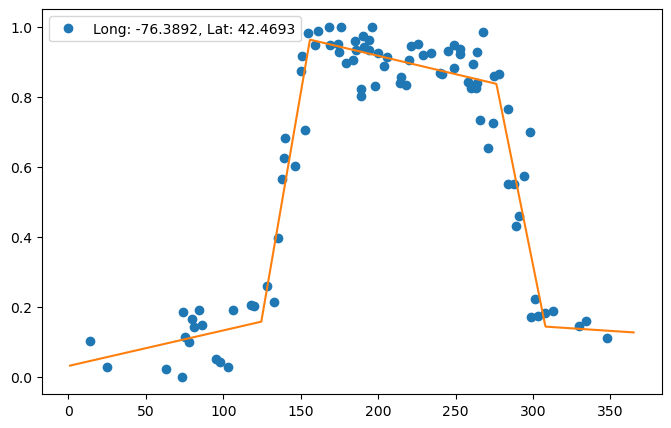

In [29]:
model = pwlf.PiecewiseLinFit(clean_df_15['doy'], clean_df_15['EVI_nrml'])
model.fit_guess([120, 150, 275, 310, 490, 540, 650])

X_grid = np.linspace(1, 365, 1000)
y_pred = model.predict(X_grid)

mask = clean_df_15['doy'] <=365
plt.figure(figsize = (8, 5))
plt.plot((clean_df_15.loc[mask])['doy'], (clean_df_15.loc[mask])['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.plot(X_grid, y_pred)
plt.legend()
plt.show()

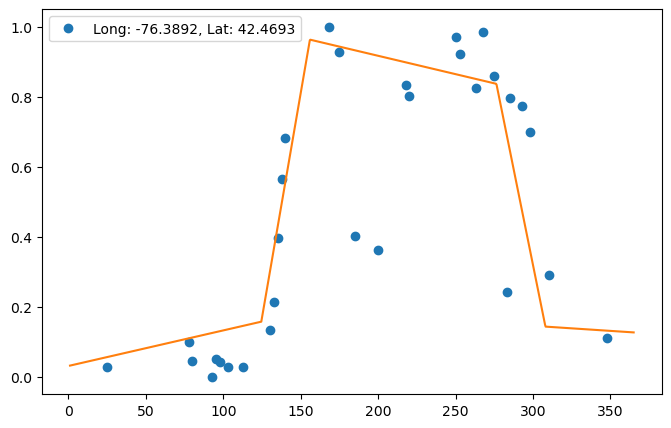

In [34]:
mask = (df['doy'] <=365) & (df['Year'] == 2021)
plt.figure(figsize = (8, 5))
plt.plot((df.loc[mask])['doy'], (df.loc[mask])['EVI_nrml'], 'o', label=f'Long: {coords[0]}, Lat: {coords[1]}')
plt.plot(X_grid, y_pred)
plt.legend()
plt.show()

In [31]:
clean_df_15

,system_index,EVI,Date,Year,doy,EVI_nrml,EVI_nrml_z_score,anomaly
2,20190114T160619_20190114T160808_T18TUN,0.074971,2019-01-14,2019,14,0.103436,0.707107,0.058276
166,20210125T155531_20210125T155631_T18TUN,0.130556,2021-01-25,2021,25,0.027783,-0.707107,-0.028551
248,20220304T160151_20220304T160221_T18TUN,0.057922,2022-03-04,2022,63,0.022916,-0.390300,-0.072022
250,20220314T160031_20220314T161104_T18TUN,0.043013,2022-03-14,2022,73,0.000000,-0.745993,-0.105097
13,20190315T160019_20190315T161019_T18TUN,0.131464,2019-03-15,2019,74,0.185626,0.836134,0.079513
...,...,...,...,...,...,...,...,...
313,20221104T160429_20221104T160701_T18TUN,0.161201,2022-11-04,2022,673,0.181666,-0.220067,-0.164786
315,20221109T160501_20221109T160502_T18TUN,0.166029,2022-11-09,2022,678,0.189087,-0.081535,-0.101714
161,20201129T160621_20201129T160754_T18TUN,0.166523,2020-11-29,2020,699,0.159413,-0.136919,0.102347
236,20211214T160651_20211214T160852_T18TUN,0.178263,2021-12-14,2021,713,0.111582,-0.915370,0.210339
